# 第2章：数据系统基础

## 本章学习目标

- 掌握 qlib 数据架构
- 熟练使用核心数据 API
- 理解数据缓存机制
- 学会使用表达式引擎

---

## 2.1 数据架构概览

Qlib 数据系统采用三层架构：

```
┌─────────────────────────────────────────────────────┐
│                    用户 API 层                       │
│            D.features(), D.calendar()               │
├─────────────────────────────────────────────────────┤
│                   Provider 层                        │
│     LocalProvider, FileStorage, PITProvider         │
├─────────────────────────────────────────────────────┤
│                   Storage 层                         │
│       文件存储、数据库存储、二进制格式               │
└─────────────────────────────────────────────────────┘
```

- **API 层**：提供统一的数据访问接口
- **Provider 层**：负责数据读取和缓存管理
- **Storage 层**：数据的持久化存储

In [1]:
import qlib
from qlib.data import D
import pandas as pd
import numpy as np

# 初始化 qlib
qlib.init(
    provider_uri="~/.qlib/qlib_data/cn_data",
    region="cn",
)

print("Qlib 初始化成功")

[80470:MainThread](2026-04-03 22:09:48,767) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[80470:MainThread](2026-04-03 22:09:49,231) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[80470:MainThread](2026-04-03 22:09:49,232) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/wutong/.qlib/qlib_data/cn_data')}


Qlib 初始化成功


## 2.2 核心数据 API

### 2.2.1 交易日历 `D.calendar()`

In [2]:
# 获取日频率交易日历
calendar_day = D.calendar(freq="day")
print(f"日频交易日历: {len(calendar_day)} 个交易日")
print(f"时间范围: {calendar_day[0]} ~ {calendar_day[-1]}")

日频交易日历: 4943 个交易日
时间范围: 1999-11-10 00:00:00 ~ 2020-09-25 00:00:00


In [ ]:
# 指定时间范围（数据只到 2020-09-25）
calendar_range = D.calendar(
    freq="day",
    start_time="2020-01-01",
    end_time="2020-12-31"
)
print(f"2020年交易日数量: {len(calendar_range)}")
print(f"\n前 5 个交易日: {calendar_range[:5]}")
print(f"后 5 个交易日: {calendar_range[-5:]}")

In [5]:
# 不同频率的交易日历
calendar_week = D.calendar(freq="week")
print(f"周频交易日历: {len(calendar_week)} 周")

calendar_month = D.calendar(freq="month")
print(f"月频交易日历: {len(calendar_month)} 月")

周频交易日历: 1022 周
月频交易日历: 250 月


### 2.2.2 股票列表 `D.instruments()`

In [7]:
# 获取沪深300成分股
# 注意：D.instruments() 返回配置字典，需要用 D.list_instruments() 获取实际列表
csi300_config = D.instruments(market="csi300")
csi300 = D.list_instruments(csi300_config, as_list=True)
print(f"沪深300成分股数量: {len(csi300)}")
print(f"\n前 10 只股票: {csi300[:10]}")

沪深300成分股数量: 690

前 10 只股票: ['SH600000', 'SH600004', 'SH600009', 'SH600010', 'SH600011', 'SH600015', 'SH600016', 'SH600018', 'SH600019', 'SH600025']


In [8]:
# 获取全市场股票
all_stocks_config = D.instruments(market="all")
all_stocks = D.list_instruments(all_stocks_config, as_list=True)
print(f"全市场股票数量: {len(all_stocks)}")

# 注意：D.instruments() 的 start_time 和 end_time 参数目前不影响结果
# 它返回的是股票池配置，不是时间点的成分股

全市场股票数量: 3875


### 2.2.3 特征数据 `D.features()`

In [9]:
# 基本用法：获取单只股票数据
# 注意：instruments 参数必须是列表
df_single = D.features(
    instruments=["SH600000"],  # 必须是列表
    fields=["$close", "$open", "$high", "$low", "$volume", "$factor"],
    start_time="2020-01-01",
    end_time="2020-12-31",
    freq="day"
)

print(f"数据形状: {df_single.shape}")
df_single.head()

数据形状: (180, 6)


$close     $open     $high      $low     $volume  \
instrument datetime                                                         
SH600000   2020-01-02  9.258679  9.258679  9.384900  9.243830  69536336.0   
           2020-01-03  9.355201  9.332926  9.377475  9.258678  51205424.0   
           2020-01-06  9.251254  9.295803  9.392324  9.221555  55222228.0   
           2020-01-07  9.280953  9.288379  9.355202  9.251254  38279312.0   
           2020-01-08  9.147306  9.147306  9.147306  9.147306  47463520.0   

                        $factor  
instrument datetime              
SH600000   2020-01-02  0.742476  
           2020-01-03  0.742476  
           2020-01-06  0.742476  
           2020-01-07  0.742476  
           2020-01-08  0.742476

In [10]:
# 获取多只股票数据
df_multi = D.features(
    instruments=["SH600000", "SH600016", "SH600019"],
    fields=["$close", "$volume"],
    start_time="2020-01-01",
    end_time="2020-03-31",
    freq="day"
)

print(f"数据形状: {df_multi.shape}")
print(f"\n索引层级: {df_multi.index.names}")
df_multi.head(10)

数据形状: (174, 2)

索引层级: ['instrument', 'datetime']


$close     $volume
instrument datetime                        
SH600000   2020-01-02  9.258679  69536336.0
           2020-01-03  9.355201  51205424.0
           2020-01-06  9.251254  55222228.0
           2020-01-07  9.280953  38279312.0
           2020-01-08  9.147306  47463520.0
           2020-01-09  9.184431  35221932.0
           2020-01-10  9.199281  24675876.0
           2020-01-13  9.214130  27900644.0
           2020-01-14  9.228980  40398008.0
           2020-01-15  9.095334  42960592.0

In [12]:
# 获取市场成分股数据
# 可以直接使用 D.instruments() 返回的配置字典
df_market = D.features(
    instruments=D.instruments("csi300"),  # 使用配置字典
    fields=["$close", "$volume"],
    start_time="2020-01-01",
    end_time="2020-12-31",
    freq="day"
)

print(f"数据形状: {df_market.shape}")
print(f"股票数量: {len(df_market.index.get_level_values('instrument').unique())}")
df_market.head()

数据形状: (54000, 2)
股票数量: 321


$close     $volume
instrument datetime                        
SH600000   2020-01-02  9.258679  69536336.0
           2020-01-03  9.355201  51205424.0
           2020-01-06  9.251254  55222228.0
           2020-01-07  9.280953  38279312.0
           2020-01-08  9.147306  47463520.0

## 2.3 数据字段说明

Qlib 内置数据集包含以下主要字段：

| 字段 | 说明 |
|------|------|
| `$open` | 开盘价 |
| `$close` | 收盘价 |
| `$high` | 最高价 |
| `$low` | 最低价 |
| `$volume` | 成交量（股） |
| `$factor` | 复权因子 |
| `$vwap` | 成交量加权平均价 |
| `$amount` | 成交额（元） |
| `$turnover` | 换手率 |
| `$adjclose` | 后复权收盘价 |

In [15]:
# 查看可用字段
from qlib.data import D

# 通过获取一条数据来查看字段
sample = D.features(
    instruments=["SH600000"],  # 必须是列表
    fields=["$open", "$close", "$high", "$low", "$volume", "$factor", "$vwap", "$amount"],
    start_time="2020-06-01",
    end_time="2020-12-31",
)

sample.tail(5)

$open    $close     $high      $low     $volume  \
instrument datetime                                                         
SH600000   2020-09-21  7.782040  7.703750  7.805528  7.695921  71527160.0   
           2020-09-22  7.680264  7.594144  7.703750  7.586315  84240616.0   
           2020-09-23  7.601973  7.539341  7.609802  7.531512  53531116.0   
           2020-09-24  7.523683  7.437563  7.531512  7.406248  68793768.0   
           2020-09-25  7.437563  7.414077  7.461051  7.406248  37664392.0   

                        $factor  $vwap  $amount  
instrument datetime                              
SH600000   2020-09-21  0.782901    NaN      NaN  
           2020-09-22  0.782901    NaN      NaN  
           2020-09-23  0.782901    NaN      NaN  
           2020-09-24  0.782901    NaN      NaN  
           2020-09-25  0.782901    NaN      NaN

## 2.4 表达式引擎

Qlib 支持使用表达式来计算衍生特征，无需手动预计算。

### 2.4.1 基本表达式

In [16]:
# 使用表达式计算收益率
df_expr = D.features(
    instruments=["SH600000"],  # 必须是列表
    fields=[
        "$close",
        "Ref($close, 1)",           # 前一日收盘价
        "($close / Ref($close, 1) - 1)",  # 日收益率
    ],
    start_time="2020-01-01",
    end_time="2020-12-31",
)

# 重命名列
df_expr.columns = ["close", "prev_close", "daily_return"]
df_expr.head()

close  prev_close  daily_return
instrument datetime                                      
SH600000   2020-01-02  9.258679    9.184431      0.008084
           2020-01-03  9.355201    9.258679      0.010425
           2020-01-06  9.251254    9.355201     -0.011111
           2020-01-07  9.280953    9.251254      0.003210
           2020-01-08  9.147306    9.280953     -0.014400

In [ ]:
# 验证计算结果
df_expr["manual_return"] = df_expr["close"].pct_change()
df_expr[["daily_return", "manual_return"]].head()

### 2.4.2 常用操作符

In [17]:
# 常用操作符示例
df_ops = D.features(
    instruments=["SH600000"],  # 必须是列表
    fields=[
        "$close",
        "Mean($close, 5)",         # 5日均线
        "Mean($close, 20)",        # 20日均线
        "Std($close, 20)",         # 20日标准差
        "Max($high, 20)",          # 20日最高价
        "Min($low, 20)",           # 20日最低价
        "Sum($volume, 5)",         # 5日成交量之和
        "Ref($close, 5)",          # 5日前收盘价
    ],
    start_time="2020-01-01",
    end_time="2020-12-31",
)

# 重命名列
df_ops.columns = ["close", "ma5", "ma20", "std20", "high20", "low20", "vol5", "close_5d_ago"]
df_ops.head(25)

close       ma5      ma20     std20    high20  \
instrument datetime                                                       
SH600000   2020-01-02  9.258679  9.175522  9.051899  0.156936  9.384900   
           2020-01-03  9.355201  9.221555  9.078257  0.161561  9.384900   
           2020-01-06  9.251254  9.242345  9.098304  0.156587  9.392324   
           2020-01-07  9.280953  9.266104  9.120578  0.148718  9.392324   
           2020-01-08  9.147306  9.258678  9.137655  0.128963  9.392324   
           2020-01-09  9.184431  9.243829  9.152133  0.115860  9.392324   
           2020-01-10  9.199281  9.212646  9.170324  0.088964  9.392324   
           2020-01-13  9.214130  9.205220  9.181090  0.079657  9.392324   
           2020-01-14  9.228980  9.194826  9.192227  0.068748  9.392324   
           2020-01-15  9.095334  9.184431  9.187030  0.072037  9.392324   
           2020-01-16  9.058210  9.159187  9.179605  0.077359  9.392324   
           2020-01-17  9.080484  9.135427  9.172923  0.079948  9.392324   
           2020-01-20  9.095334  9.111669  9.166612  0.080884  9.392324   
           2020-01-21  8.969113  9.059695  9.162157  0.089195  9.392324   
           2020-01-22  8.738946  8.988418  9.143224  0.130003  9.392324   
           2020-01-23  8.427106  8.862197  9.110184  0.206352  9.392324   
           2020-02-03  7.773727  8.600845  9.042619  0.363002  9.392324   
           2020-02-04  7.914796  8.364738  8.980993  0.440616  9.392324   
           2020-02-05  7.944496  8.159814  8.920110  0.495032  9.392324   
           2020-02-06  8.011319  8.014289  8.861454  0.530308  9.392324   
           2020-02-07  8.063293  7.941526  8.801684  0.550174  9.392324   
           2020-02-10  7.996469  7.986074  8.733748  0.561990  9.392324   
           2020-02-11  8.063293  8.015774  8.674350  0.567170  9.355202   
           2020-02-12  8.063293  8.039534  8.613467  0.563973  9.243829   
           2020-02-13  7.989045  8.035078  8.555554  0.565736  9.243829   

                          low20         vol5  close_5d_ago  
instrument datetime                                         
SH600000   2020-01-02  8.731521  226681216.0      9.087909  
           2020-01-03  8.783494  256688592.0      9.125033  
           2020-01-06  8.798344  274290624.0      9.147306  
           2020-01-07  8.798344  257279872.0      9.162157  
           2020-01-08  8.798344  261706816.0      9.184431  
           2020-01-09  8.820619  227392416.0      9.258679  
           2020-01-10  8.865166  200862864.0      9.355201  
           2020-01-13  8.909716  173541280.0      9.251254  
           2020-01-14  8.983963  175659984.0      9.280953  
           2020-01-15  8.998813  171157056.0      9.147306  
           2020-01-16  8.998813  166178336.0      9.184431  
           2020-01-17  8.998813  165197648.0      9.199281  
           2020-01-20  8.998813  169263840.0      9.214130  
           2020-01-21  8.939414  171678608.0      9.228980  
           2020-01-22  8.649848  233951760.0      9.095334  
           2020-01-23  8.404831  306788992.0      9.058210  
           2020-02-03  7.588108  411538848.0      9.080484  
           2020-02-04  7.588108  469519360.0      9.095334  
           2020-02-05  7.588108  487377408.0      8.969113  
           2020-02-06  7.588108  433355808.0      8.738946  
           2020-02-07  7.588108  373235584.0      8.427106  
           2020-02-10  7.588108  290626528.0      7.773727  
           2020-02-11  7.588108  247625216.0      7.914796  
           2020-02-12  7.588108  222395136.0      7.944496  
           2020-02-13  7.588108  201662912.0      8.011319

### 2.4.3 技术指标表达式

In [18]:
# 技术指标计算
df_tech = D.features(
    instruments=["SH600000"],  # 必须是列表
    fields=[
        "$close",
        # 布林带
        "Mean($close, 20)",                              # 中轨
        "Mean($close, 20) + 2 * Std($close, 20)",        # 上轨
        "Mean($close, 20) - 2 * Std($close, 20)",        # 下轨
        # 动量
        "$close / Ref($close, 20) - 1",                  # 20日动量
        # 波动率
        "Std($close / Ref($close, 1) - 1, 20)",          # 20日波动率
    ],
    start_time="2020-01-01",
    end_time="2020-12-31",
)

df_tech.columns = ["close", "boll_mid", "boll_upper", "boll_lower", "momentum_20d", "volatility_20d"]
df_tech.head(25)

close  boll_mid  boll_upper  boll_lower  \
instrument datetime                                                 
SH600000   2020-01-02  9.258679  9.051899    9.365771    8.738028   
           2020-01-03  9.355201  9.078257    9.401379    8.755136   
           2020-01-06  9.251254  9.098304    9.411477    8.785131   
           2020-01-07  9.280953  9.120578    9.418014    8.823142   
           2020-01-08  9.147306  9.137655    9.395582    8.879728   
           2020-01-09  9.184431  9.152133    9.383854    8.920413   
           2020-01-10  9.199281  9.170324    9.348251    8.992396   
           2020-01-13  9.214130  9.181090    9.340405    9.021775   
           2020-01-14  9.228980  9.192227    9.329723    9.054731   
           2020-01-15  9.095334  9.187030    9.331104    9.042955   
           2020-01-16  9.058210  9.179605    9.334322    9.024888   
           2020-01-17  9.080484  9.172923    9.332819    9.013026   
           2020-01-20  9.095334  9.166612    9.328379    9.004845   
           2020-01-21  8.969113  9.162157    9.340547    8.983768   
           2020-01-22  8.738946  9.143224    9.403229    8.883219   
           2020-01-23  8.427106  9.110184    9.522888    8.697479   
           2020-02-03  7.773727  9.042619    9.768622    8.316614   
           2020-02-04  7.914796  8.980993    9.862225    8.099761   
           2020-02-05  7.944496  8.920110    9.910173    7.930046   
           2020-02-06  8.011319  8.861454    9.922070    7.800838   
           2020-02-07  8.063293  8.801684    9.902032    7.701338   
           2020-02-10  7.996469  8.733748    9.857727    7.609769   
           2020-02-11  8.063293  8.674350    9.808690    7.540010   
           2020-02-12  8.063293  8.613467    9.741412    7.485522   
           2020-02-13  7.989045  8.555554    9.687025    7.424083   

                       momentum_20d  volatility_20d  
instrument datetime                                  
SH600000   2020-01-02      0.061277        0.008571  
           2020-01-03      0.059714        0.008495  
           2020-01-06      0.045302        0.009059  
           2020-01-07      0.050420        0.009013  
           2020-01-08      0.038786        0.009702  
           2020-01-09      0.032554        0.009527  
           2020-01-10      0.041176        0.009324  
           2020-01-13      0.023927        0.008485  
           2020-01-14      0.024732        0.008485  
           2020-01-15     -0.011299        0.007759  
           2020-01-16     -0.016129        0.007791  
           2020-01-17     -0.014504        0.007818  
           2020-01-20     -0.013688        0.007828  
           2020-01-21     -0.009836        0.007425  
           2020-01-22     -0.041531        0.009122  
           2020-01-23     -0.072712        0.011824  
           2020-02-03     -0.148088        0.020149  
           2020-02-04     -0.134740        0.020862  
           2020-02-05     -0.132901        0.020914  
           2020-02-06     -0.127728        0.021096  
           2020-02-07     -0.129110        0.021041  
           2020-02-10     -0.145238        0.020653  
           2020-02-11     -0.128411        0.020936  
           2020-02-12     -0.131200        0.020869  
           2020-02-13     -0.126623        0.020801

## 2.5 数据缓存机制

Qlib 提供多层缓存来加速数据访问。

```
┌─────────────────────────────────────────┐
│           内存缓存 (最快)                │
│        CacheTemp, MemCache              │
├─────────────────────────────────────────┤
│           磁盘缓存 (较快)                │
│        FileStorage Cache                │
├─────────────────────────────────────────┤
│           原始数据 (最慢)                │
│        Binary/CSV Files                 │
└─────────────────────────────────────────┘
```

In [19]:
import time

# 测试缓存效果
def test_cache_performance():
    """测试缓存对数据访问速度的影响"""
    
    # 第一次访问（可能需要从磁盘加载）
    start = time.time()
    df1 = D.features(
        instruments=D.instruments("csi300"),  # 使用配置字典
        fields=["$close", "$volume"],
        start_time="2019-01-01",
        end_time="2020-09-25",
    )
    time1 = time.time() - start
    
    # 第二次访问（应该命中缓存）
    start = time.time()
    df2 = D.features(
        instruments=D.instruments("csi300"),
        fields=["$close", "$volume"],
        start_time="2019-01-01",
        end_time="2020-09-25",
    )
    time2 = time.time() - start
    
    print(f"第一次访问: {time1:.4f} 秒")
    print(f"第二次访问: {time2:.4f} 秒 (缓存)")
    print(f"加速比: {time1/time2:.2f}x")
    
test_cache_performance()

第一次访问: 5.4237 秒
第二次访问: 5.1019 秒 (缓存)
加速比: 1.06x


## 2.6 数据可视化实战

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 获取数据
df = D.features(
    instruments=["SH600000"],  # 必须是列表
    fields=["$open", "$close", "$high", "$low", "$volume"],
    start_time="2020-01-01",
    end_time="2020-09-25",
)

# 计算均线
df["ma5"] = df["$close"].rolling(5).mean()
df["ma20"] = df["$close"].rolling(20).mean()

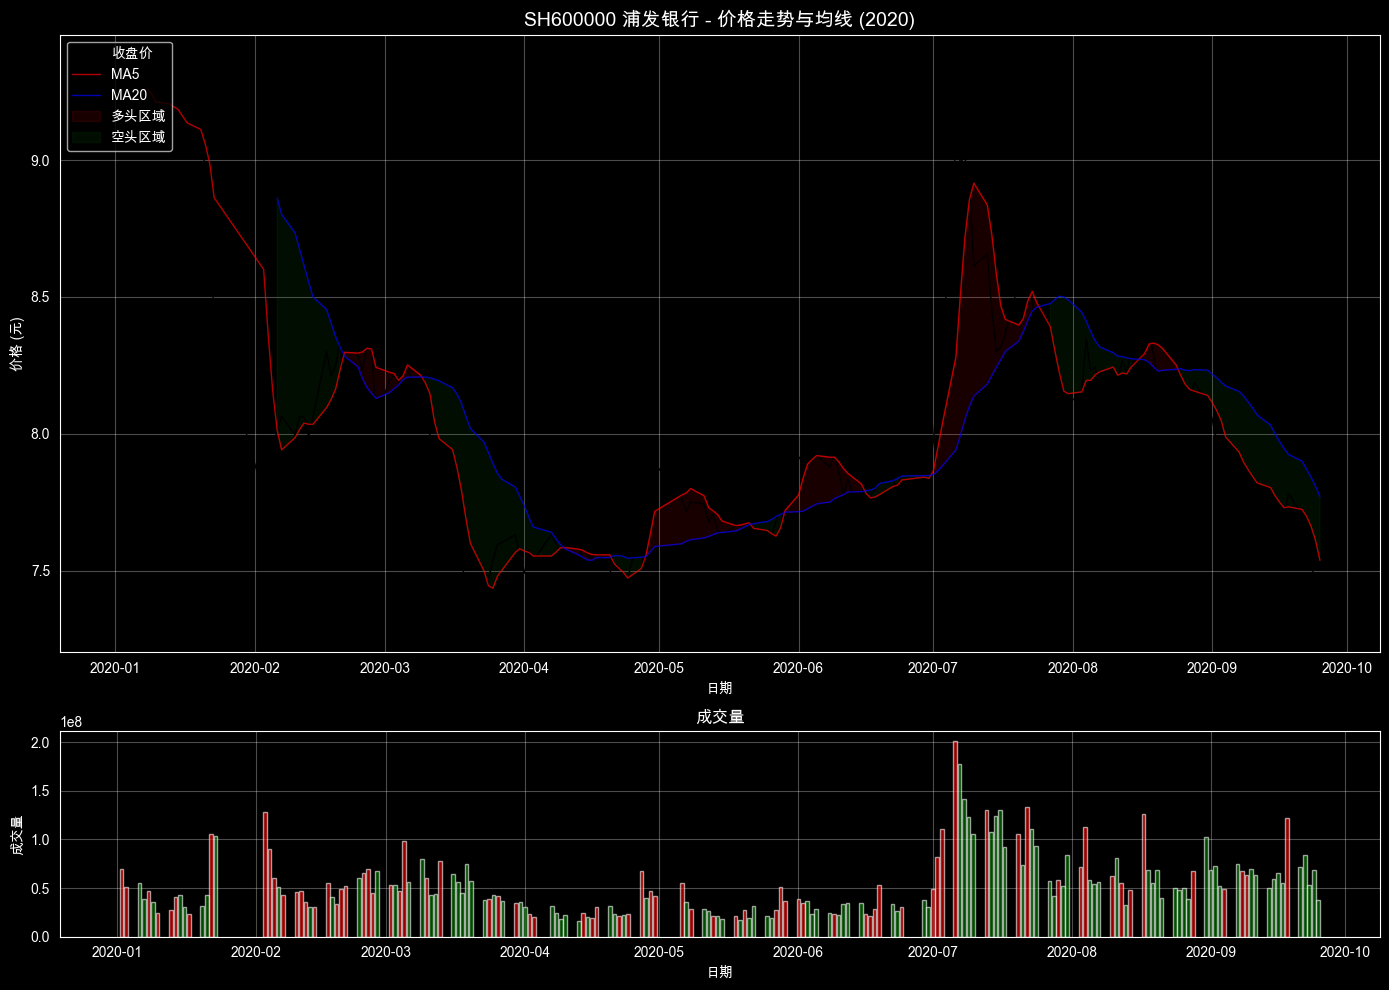

In [21]:
# 绘制 K 线图和均线
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

dates = df.index.get_level_values('datetime')

# 收盘价和均线
ax1.plot(dates, df['$close'], label='收盘价', color='black', linewidth=1)
ax1.plot(dates, df['ma5'], label='MA5', color='red', linewidth=1, alpha=0.7)
ax1.plot(dates, df['ma20'], label='MA20', color='blue', linewidth=1, alpha=0.7)

# 填充均线之间的区域
ax1.fill_between(dates, df['ma5'], df['ma20'], 
                  where=(df['ma5'] >= df['ma20']), 
                  color='red', alpha=0.1, label='多头区域')
ax1.fill_between(dates, df['ma5'], df['ma20'], 
                  where=(df['ma5'] < df['ma20']), 
                  color='green', alpha=0.1, label='空头区域')

ax1.set_title('SH600000 浦发银行 - 价格走势与均线 (2020)', fontsize=14)
ax1.set_xlabel('日期')
ax1.set_ylabel('价格 (元)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 成交量
colors = ['red' if df['$close'].iloc[i] >= df['$open'].iloc[i] else 'green' 
          for i in range(len(df))]
ax2.bar(dates, df['$volume'], color=colors, alpha=0.6)
ax2.set_title('成交量', fontsize=12)
ax2.set_xlabel('日期')
ax2.set_ylabel('成交量')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.7 实践练习

### 练习目标

1. 获取指定时间范围的交易日历
2. 查询沪深300成分股的行情数据
3. 使用表达式计算技术指标（MA5、MA20、RSI）
4. 绘制 K 线图和技术指标

In [26]:
# 练习1: 计算 RSI 指标
# RSI = 100 - 100 / (1 + RS)
# RS = 平均上涨幅度 / 平均下跌幅度

# 提示：使用表达式计算，或者获取数据后手动计算

# 你的代码

df = D.features(instruments=["SH600000"], fields=["$close"], start_time="2020-01-01", end_time="2020-09-25")
delta = df["$close"].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df["rsi"] = 100 - (100 / (1 + rs))
df

# 参考答案（手动计算方式）
# df = D.features(instruments=["SH600000"], fields=["$close"], start_time="2020-01-01", end_time="2020-09-25")
# delta = df["$close"].diff()
# gain = delta.where(delta > 0, 0).rolling(14).mean()
# loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
# rs = gain / loss
# df["rsi"] = 100 - (100 / (1 + rs))

$close        rsi
instrument datetime                       
SH600000   2020-01-02  9.258679        NaN
           2020-01-03  9.355201        NaN
           2020-01-06  9.251254        NaN
           2020-01-07  9.280953        NaN
           2020-01-08  9.147306        NaN
...                         ...        ...
           2020-09-21  7.703750  20.000016
           2020-09-22  7.594144  19.230784
           2020-09-23  7.539341  18.987381
           2020-09-24  7.437563  17.241403
           2020-09-25  7.414077  17.857169

[180 rows x 2 columns]

In [ ]:
# 练习2: 获取沪深300所有成分股 2020年的收盘价
# 计算每只股票的年化收益率和波动率
# 找出收益率最高的 10 只股票

# 你的代码



# 参考答案
# df = D.features(instruments=D.instruments("csi300"), fields=["$close"], start_time="2020-01-01", end_time="2020-09-25")
# # 按 instrument 分组计算
# returns = df["$close"].groupby("instrument").apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
# print(returns.nlargest(10))

In [ ]:
# 练习3: 绘制 SH600000 的 MACD 指标
# MACD = EMA(12) - EMA(26)
# Signal = EMA(MACD, 9)
# Histogram = MACD - Signal

# 你的代码



# 参考答案
# df = D.features(instruments='SH600000', fields=['$close'], start_time='2022-01-01', end_time='2023-12-31')
# ema12 = df['$close'].ewm(span=12, adjust=False).mean()
# ema26 = df['$close'].ewm(span=26, adjust=False).mean()
# macd = ema12 - ema26
# signal = macd.ewm(span=9, adjust=False).mean()
# histogram = macd - signal
# 
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
# ax1.plot(df.index.get_level_values('datetime'), df['$close'], label='收盘价')
# ax2.plot(df.index.get_level_values('datetime'), macd, label='MACD')
# ax2.plot(df.index.get_level_values('datetime'), signal, label='Signal')
# ax2.bar(df.index.get_level_values('datetime'), histogram, label='Histogram', alpha=0.5)
# plt.legend()
# plt.show()

## 2.8 本章小结

本章我们学习了：

1. **数据架构**：Provider、Storage、Cache 三层结构
2. **核心 API**：
   - `D.calendar()` - 交易日历
   - `D.instruments()` - 股票列表
   - `D.features()` - 特征数据
3. **表达式引擎**：使用表达式动态计算衍生特征
4. **数据缓存**：多层次缓存机制加速数据访问

### 常用操作符速查

| 操作符 | 说明 | 示例 |
|--------|------|------|
| `Ref` | 引用历史值 | `Ref($close, 5)` |
| `Mean` | 移动平均 | `Mean($close, 20)` |
| `Std` | 标准差 | `Std($close, 20)` |
| `Sum` | 求和 | `Sum($volume, 5)` |
| `Max` | 最大值 | `Max($high, 20)` |
| `Min` | 最小值 | `Min($low, 20)` |
| `Corr` | 相关系数 | `Corr($close, $volume, 20)` |
| `Cov` | 协方差 | `Cov($close, $volume, 20)` |

### 下一章预告

下一章我们将学习 qlib 的工作流系统，包括：
- YAML 配置驱动的工作流
- `qrun` 命令行工具
- Recorder 实验管理模式